In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Download and load boston housing dataset using kagglehub
import kagglehub
import os

path = kagglehub.dataset_download("vikrishnan/boston-house-prices")
print("Path to dataset files:", path)

# Load dataset
df = pd.read_csv(os.path.join(path, "housing.csv"), 
                 header=None,
                 sep='\s+',
                 names=['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
                        'DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE'])

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

100%|██████████| 12.8k/12.8k [00:00<00:00, 2.75MB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\vikrishnan\boston-house-prices\versions\1

Dataset loaded successfully!
Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [4]:
# Check missing values
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Any Missing Values? ===")
print(df.isnull().values.any())

=== Missing Values ===
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

=== Any Missing Values? ===
False


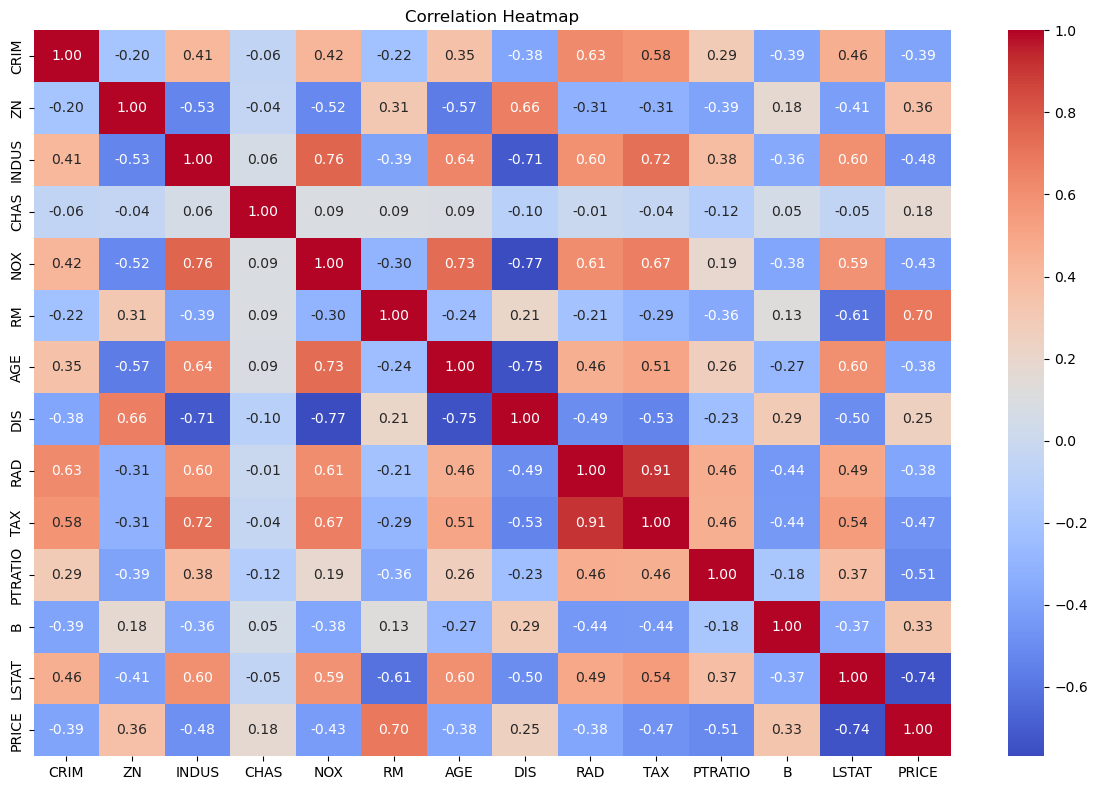

In [8]:
# Correlation heatmap to find most related features with PRICE
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

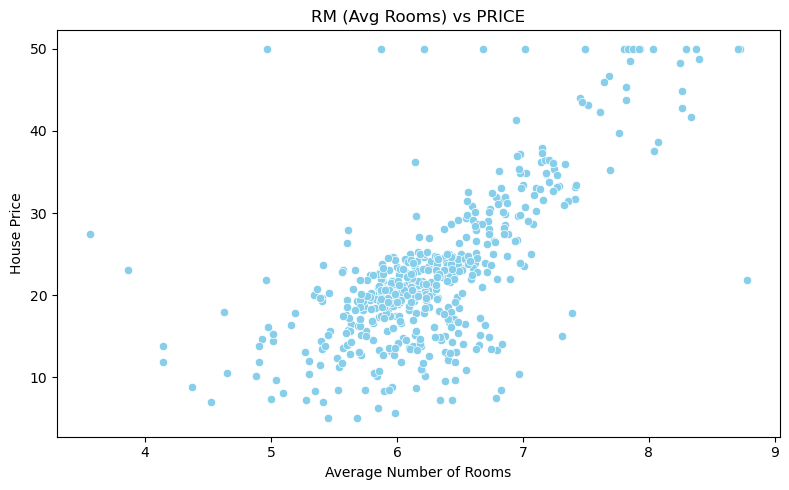

In [9]:
# Scatter plot of most correlated feature RM vs PRICE
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['RM'], y=df['PRICE'], color='skyblue')
plt.title('RM (Avg Rooms) vs PRICE')
plt.xlabel('Average Number of Rooms')
plt.ylabel('House Price')
plt.tight_layout()
plt.show()

In [ ]:
# RM has highest positive correlation with PRICE 
# - scatter plot confirms linear relationship.

In [10]:
# Prepare independent and dependent variables
X = df.drop('PRICE', axis=1)  # Independent variables
Y = df['PRICE']                # Dependent variable

print("=== Features (X) ===")
print(X.head())

print("\n=== Target (Y) ===")
print(Y.head())

print(f"\nX Shape: {X.shape}")
print(f"Y Shape: {Y.shape}")
print("Features and target prepared successfully!")

=== Features (X) ===
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  

=== Target (Y) ===
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: PRICE, dtype: float64

X Shape: (506, 13)
Y Shape: (506,)
Features and target prepared successfully!


In [11]:
# Split dataset into 80% training and 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.20, random_state=10)

print("=== Data Split Successfully ===")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"Y_train Shape: {Y_train.shape}")
print(f"Y_test Shape:  {Y_test.shape}")

=== Data Split Successfully ===
X_train Shape: (404, 13)
X_test Shape:  (102, 13)
Y_train Shape: (404,)
Y_test Shape:  (102,)


In [ ]:
#Train the linear regression model on training data 
# to learn relationship between features and price.

In [12]:
# Initialize and train linear regression model
reg = LinearRegression()
reg.fit(X_train, Y_train)

print("Model trained successfully!")
print(f"\n=== Model Coefficients ===")
coef_df = pd.DataFrame(reg.coef_, X.columns, columns=['Coefficient'])
print(coef_df)

print(f"\nIntercept: {reg.intercept_:.4f}")

Model trained successfully!

=== Model Coefficients ===
         Coefficient
CRIM       -0.128181
ZN          0.063198
INDUS      -0.007576
CHAS        1.974515
NOX       -16.271989
RM          3.108456
AGE         0.016292
DIS        -1.483014
RAD         0.303988
TAX        -0.012082
PTRATIO    -0.820306
B           0.011419
LSTAT      -0.581626

Intercept: 36.5331


In [13]:
# Predict on test data
Y_pred = reg.predict(X_test)

print("=== Actual vs Predicted Prices ===")
comparison = pd.DataFrame({'Actual': Y_test.values, 
                           'Predicted': Y_pred.round(2)})
print(comparison.head(10))

=== Actual vs Predicted Prices ===
   Actual  Predicted
0    28.4      31.08
1    31.1      31.72
2    23.5      30.87
3    26.6      22.28
4    19.6      18.86
5    14.3      16.47
6    50.0      36.05
7    14.3      14.64
8    20.7      25.24
9    37.6      36.92


In [14]:
# Evaluate model performance
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2   = round(reg.score(X_test, Y_test), 2)

print("=== Model Performance ===")
print(f"Root Mean Squared Error : {rmse:.4f}")
print(f"R² Score                : {r2}")

print("\n=== Interpretation ===")
print(f"R² = {r2} means model explains {r2*100}% variance in house prices")

=== Model Performance ===
Root Mean Squared Error : 5.8663
R² Score                : 0.67

=== Interpretation ===
R² = 0.67 means model explains 67.0% variance in house prices


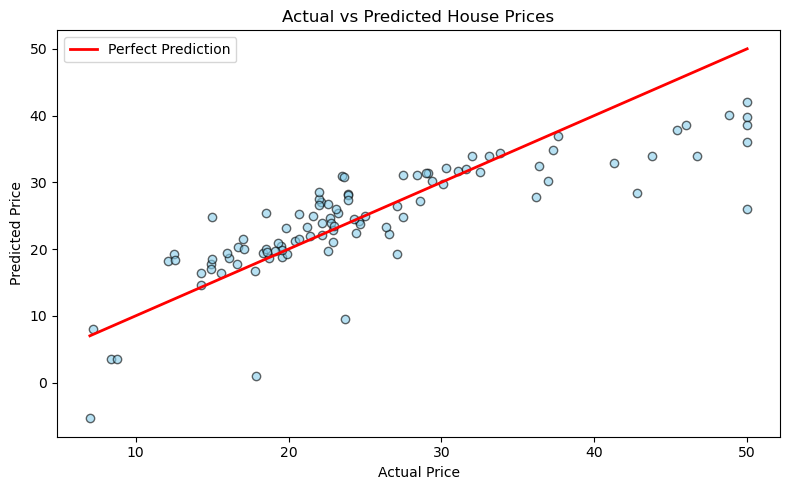

In [15]:
# Plot actual vs predicted prices
plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred, color='skyblue', edgecolors='black', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], 
         [Y_test.min(), Y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Points closer to red line mean better predictions

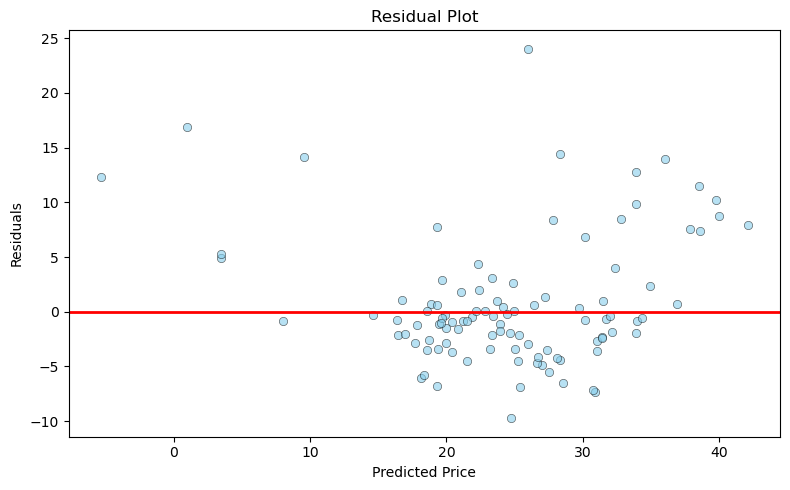

In [16]:
# Residual plot to check model errors
residuals = Y_test - Y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y_pred, y=residuals, color='skyblue', edgecolors='black', alpha=0.6)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [17]:
# Final summary of model
print("   Linear Regression Summary  ")
print("==============================")
print(f"Total Records       : {df.shape[0]}")
print(f"Total Features      : {X.shape[1]}")
print(f"Training Samples    : {X_train.shape[0]}")
print(f"Testing Samples     : {X_test.shape[0]}")
print(f"RMSE                : {rmse:.4f}")
print(f"R² Score            : {r2}")


   Linear Regression Summary  
Total Records       : 506
Total Features      : 13
Training Samples    : 404
Testing Samples     : 102
RMSE                : 5.8663
R² Score            : 0.67
